In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
#pip install --upgrade openpyxl


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
#pip install openpyxl

In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.duplicated().sum()

0

<AxesSubplot:>

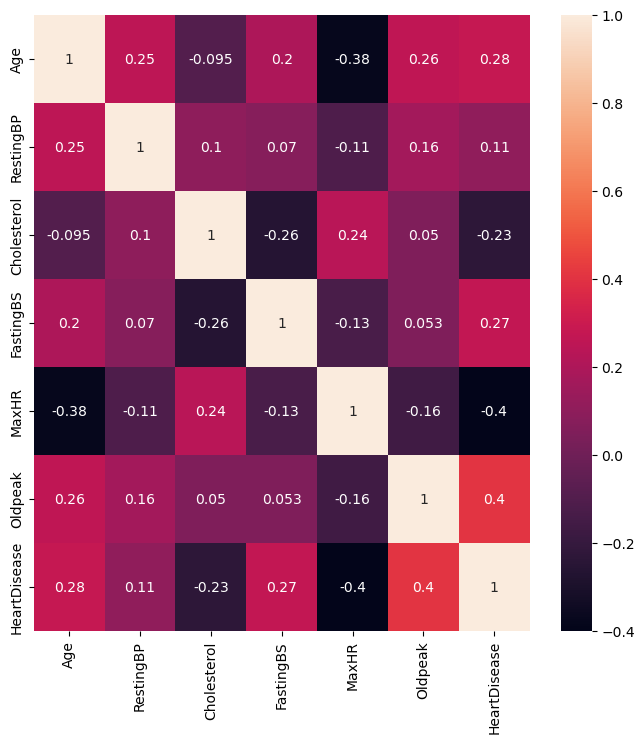

In [9]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)

# Data preprocessing for balancing


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()

In [13]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [14]:
list=['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease']
for i in list:
    df[i]=le.fit_transform(df[i])

In [15]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,12,1,1,41,147,0,1,98,0,10,2,0
1,21,0,2,55,40,0,1,82,0,20,1,1
2,9,1,1,31,141,0,2,25,0,10,2,0
3,20,0,0,39,72,0,1,34,1,25,1,1
4,26,1,2,49,53,0,1,48,0,10,2,0


In [16]:
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']

In [17]:
x.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
491,47,1,0,58,61,1,2,34,0,10,1
287,25,1,1,22,41,0,1,58,0,10,2
142,19,1,0,55,149,0,2,84,1,39,1
600,29,1,0,31,65,0,2,23,1,20,1
909,35,0,0,25,55,0,1,62,1,10,1
769,23,0,2,31,114,0,0,75,0,15,2
552,43,1,2,45,79,0,1,34,1,28,1
859,23,0,2,41,164,0,0,68,0,25,2
703,13,0,1,27,162,0,1,89,0,10,2
733,38,0,3,49,84,0,1,40,0,36,0


# Split Dataset into Train and Test


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [20]:
ytest.head(50)

668    0
30     1
377    1
535    1
807    0
793    1
363    1
583    0
165    1
483    1
773    0
551    0
768    0
694    0
718    1
312    1
713    0
309    1
846    1
616    0
355    1
39     0
231    0
822    0
603    1
63     1
192    0
481    1
866    0
67     0
72     1
655    1
679    0
139    1
732    1
824    0
174    1
896    0
499    1
70     1
716    1
23     1
541    1
799    0
672    0
826    0
250    1
752    1
350    1
758    0
Name: HeartDisease, dtype: int64

Round 1/20 → Loss: 1.4018, Accuracy: 0.4402
Round 2/20 → Loss: 0.5888, Accuracy: 0.7011
Round 3/20 → Loss: 0.8992, Accuracy: 0.5652
Round 4/20 → Loss: 0.5754, Accuracy: 0.7228
Round 5/20 → Loss: 0.9164, Accuracy: 0.5815
Round 6/20 → Loss: 0.5489, Accuracy: 0.7391
Round 7/20 → Loss: 0.5850, Accuracy: 0.7120
Round 8/20 → Loss: 0.5819, Accuracy: 0.7174
Round 9/20 → Loss: 0.5529, Accuracy: 0.7446
Round 10/20 → Loss: 0.8473, Accuracy: 0.5978
Round 11/20 → Loss: 0.5528, Accuracy: 0.7283
Round 12/20 → Loss: 0.7024, Accuracy: 0.6522
Round 13/20 → Loss: 0.5390, Accuracy: 0.7283
Round 14/20 → Loss: 0.6940, Accuracy: 0.6739
Round 15/20 → Loss: 0.5366, Accuracy: 0.7391
Round 16/20 → Loss: 0.6714, Accuracy: 0.6739
Round 17/20 → Loss: 0.5421, Accuracy: 0.7283
Round 18/20 → Loss: 0.5270, Accuracy: 0.7391
Round 19/20 → Loss: 0.7368, Accuracy: 0.6739
Round 20/20 → Loss: 0.5130, Accuracy: 0.7554

Classification Report:
               precision    recall  f1-score   support

           0       0.74      

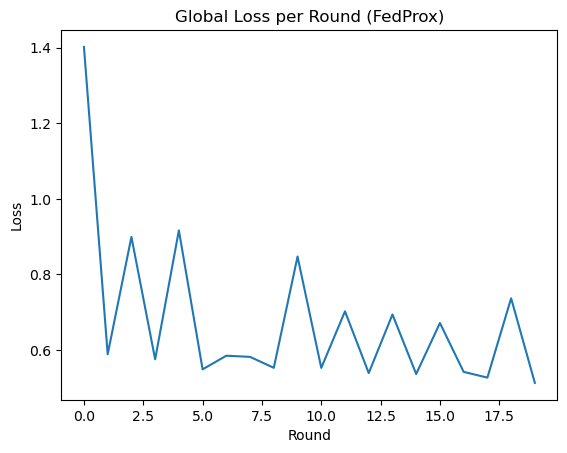

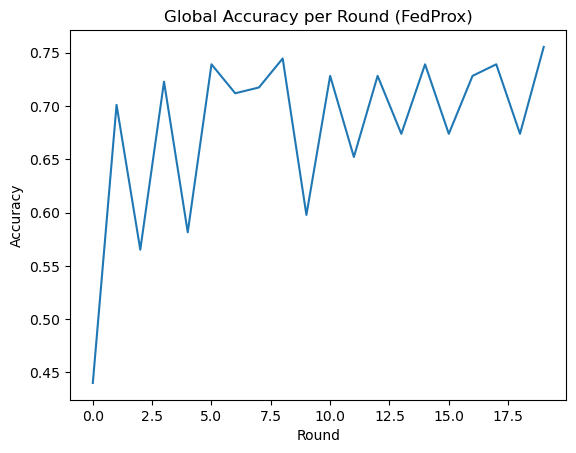

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients

    clients = []
    for i in range(n_clients):
        start = i * split_size
        end = (i + 1) * split_size
        clients.append((X[idx[start:end]], y[idx[start:end]]))

    return clients

# -------------------------------------------------
# 2. Build 1D CNN model
# -------------------------------------------------
def build_1dcnn(input_shape, n_classes):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server-side aggregation (FedProx)
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [
        np.mean(w, axis=0)
        for w in zip(*[m.get_weights() for m in local_models])
    ]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss (TensorFlow 2.x safe)
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([
            tf.reduce_sum(tf.square(w - gw))
            for w, gw in zip(local_model.trainable_variables, global_weights)
        ])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training procedure
# -------------------------------------------------
def model_fedprox_1dcnn(xtrain, ytrain, xtest, ytest,
                        rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for Conv1D
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Create 5 equal clients
    clients = split_clients_equal(xtrain, ytrain, n_clients=5)

    # Initialize global model
    global_model = build_1dcnn(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)

            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )

            local_model.fit(
                Xc, yc,
                epochs=epochs,
                batch_size=32,
                verbose=0
            )

            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)

        print(f"Round {r+1}/{rounds} → Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)

    print("\nClassification Report:\n",
          classification_report(ytest, y_pred))
    print("Confusion Matrix:\n",
          confusion_matrix(ytest, y_pred))

    # ---- PRINT FULL LISTS ----
    print("\nGlobal Loss per Round:")
    print(global_loss)

    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # ---- PLOTS ----
    plt.figure()
    plt.plot(global_loss)
    plt.title("Global Loss per Round (FedProx)")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(global_acc)
    plt.title("Global Accuracy per Round (FedProx)")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.show()

    return global_model

# -------------------------------------------------
# 6. Run FedProx
# -------------------------------------------------
global_model = model_fedprox_1dcnn(
    xtrain, ytrain, xtest, ytest,
    rounds=20,
    epochs=2,
    mu=0.01
)


In [26]:
global_loss_per_round_CNN = [1.4018083810806274, 0.5887984037399292, 0.8992260694503784, 0.5753996968269348, 0.9164484143257141, 0.5489012598991394, 0.5849560499191284, 0.5818613171577454, 0.552936315536499, 0.8472831845283508, 0.5527766942977905, 0.7024021744728088, 0.5389851927757263, 0.6940495371818542, 0.536567747592926, 0.6714328527450562, 0.5421346426010132, 0.5269885659217834, 0.736813485622406, 0.5129609107971191]

In [27]:
global_accuracy_per_round_CNN = [0.44021740555763245, 0.7010869383811951, 0.5652173757553101, 0.7228260636329651, 0.58152174949646, 0.739130437374115, 0.7119565010070801, 0.717391312122345, 0.7445651888847351, 0.5978260636329651, 0.72826087474823, 0.6521739363670349, 0.72826087474823, 0.6739130616188049, 0.739130437374115, 0.6739130616188049, 0.72826087474823, 0.739130437374115, 0.6739130616188049, 0.7554348111152649]

Round 1: Loss=0.6583, Accuracy=0.5870
Round 2: Loss=0.6490, Accuracy=0.6957
Round 3: Loss=0.6242, Accuracy=0.6848
Round 4: Loss=0.5898, Accuracy=0.7283
Round 5: Loss=0.5788, Accuracy=0.7174
Round 6: Loss=0.5706, Accuracy=0.7391
Round 7: Loss=0.5558, Accuracy=0.7391
Round 8: Loss=0.5457, Accuracy=0.7391
Round 9: Loss=0.5503, Accuracy=0.7283
Round 10: Loss=0.5480, Accuracy=0.7283
Round 11: Loss=0.5318, Accuracy=0.7446
Round 12: Loss=0.5275, Accuracy=0.7446
Round 13: Loss=0.5239, Accuracy=0.7446
Round 14: Loss=0.5282, Accuracy=0.7609
Round 15: Loss=0.5337, Accuracy=0.7500
Round 16: Loss=0.5176, Accuracy=0.7663
Round 17: Loss=0.5047, Accuracy=0.7826
Round 18: Loss=0.5059, Accuracy=0.7609
Round 19: Loss=0.4933, Accuracy=0.7772
Round 20: Loss=0.4936, Accuracy=0.7717

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.73        77
           1       0.82      0.79      0.80       107

    accuracy                           0

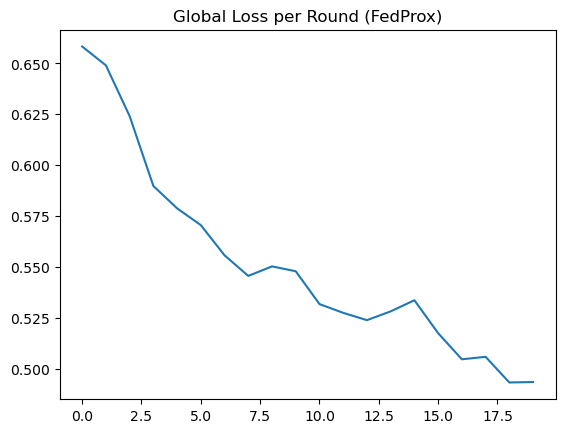

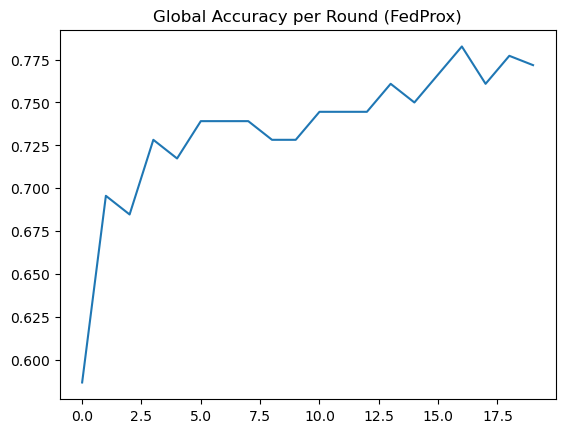

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build LSTM model
# -------------------------------------------------
def build_lstm(input_shape, n_classes):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_lstm(xtrain, ytrain, xtest, ytest,
                        n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for LSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_lstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001), 
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_lstm(xtrain, ytrain, xtest, ytest,
                                  n_clients=5, rounds=20, epochs=2, mu=0.01)


In [28]:
Global_Loss_per_Round_LSTM = [0.658302366733551, 0.649044394493103, 0.624152421951294, 0.5898331999778748, 0.5788376927375793, 0.5705968737602234, 0.5557770729064941, 0.5456543564796448, 0.5503355264663696, 0.5479511022567749, 0.5318339467048645, 0.5275214910507202, 0.5239311456680298, 0.5282444953918457, 0.5337106585502625, 0.5175621509552002, 0.5047222375869751, 0.5059319138526917, 0.4933350682258606, 0.4935535490512848]

Global_Accuracy_per_Round_LSTM = [0.5869565010070801, 0.695652186870575, 0.6847826242446899, 0.72826087474823, 0.717391312122345, 0.739130437374115, 0.739130437374115, 0.739130437374115, 0.72826087474823, 0.72826087474823, 0.7445651888847351, 0.7445651888847351, 0.7445651888847351, 0.760869562625885, 0.75, 0.7663043737411499, 0.782608687877655, 0.760869562625885, 0.7771739363670349, 0.77173912525177]


Round 1: Loss=0.6311, Accuracy=0.6848
Round 2: Loss=0.6087, Accuracy=0.6793
Round 3: Loss=0.5897, Accuracy=0.7228
Round 4: Loss=0.5664, Accuracy=0.7500
Round 5: Loss=0.5465, Accuracy=0.7717
Round 6: Loss=0.5377, Accuracy=0.7826
Round 7: Loss=0.5179, Accuracy=0.7663
Round 8: Loss=0.5100, Accuracy=0.7663
Round 9: Loss=0.5136, Accuracy=0.7772
Round 10: Loss=0.5117, Accuracy=0.7772
Round 11: Loss=0.5198, Accuracy=0.7772
Round 12: Loss=0.4977, Accuracy=0.7772
Round 13: Loss=0.5041, Accuracy=0.7826
Round 14: Loss=0.5117, Accuracy=0.7826
Round 15: Loss=0.4884, Accuracy=0.7717
Round 16: Loss=0.5084, Accuracy=0.7772
Round 17: Loss=0.4932, Accuracy=0.7826
Round 18: Loss=0.4887, Accuracy=0.7826
Round 19: Loss=0.4842, Accuracy=0.7826
Round 20: Loss=0.4810, Accuracy=0.7826

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.81      0.76        77
           1       0.85      0.77      0.80       107

    accuracy                           0

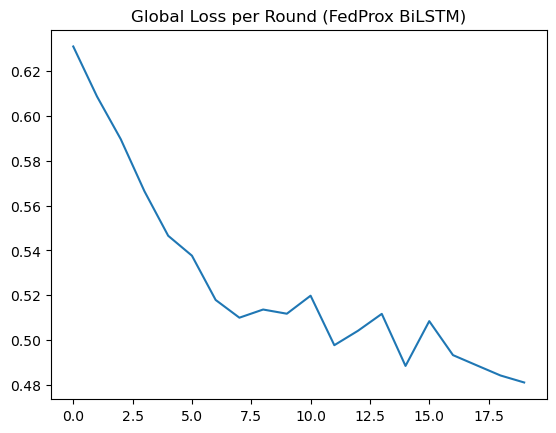

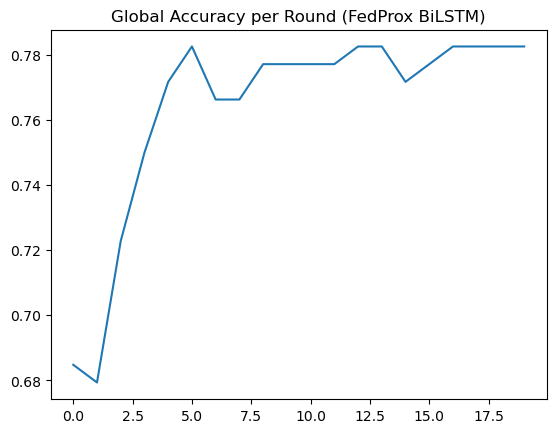

In [23]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build BiLSTM model
# -------------------------------------------------
def build_bilstm(input_shape, n_classes):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_bilstm(xtrain, ytrain, xtest, ytest,
                         n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for BiLSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_bilstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx BiLSTM)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx BiLSTM)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_bilstm(xtrain, ytrain, xtest, ytest,
                                    n_clients=5, rounds=20, epochs=2, mu=0.01)


In [29]:
Global_Loss_per_Round_BiLSTM = [0.6310575604438782, 0.6087354421615601, 0.5896958708763123, 0.5663992166519165, 0.5465351939201355, 0.5376507639884949, 0.5178743004798889, 0.5099549293518066, 0.5136023163795471, 0.5117292404174805, 0.5197775959968567, 0.4976731240749359, 0.5041353106498718, 0.5116682052612305, 0.4884168803691864, 0.5084170699119568, 0.4932444989681244, 0.48868370056152344, 0.4841597080230713, 0.4810278117656708]

Global_Accuracy_per_Round_BiLSTM = [0.6847826242446899, 0.679347813129425, 0.7228260636329651, 0.75, 0.77173912525177, 0.782608687877655, 0.7663043737411499, 0.7663043737411499, 0.7771739363670349, 0.7771739363670349, 0.7771739363670349, 0.7771739363670349, 0.782608687877655, 0.782608687877655, 0.77173912525177, 0.7771739363670349, 0.782608687877655, 0.782608687877655, 0.782608687877655, 0.782608687877655]

Round 1: Loss=0.6449, Accuracy=0.7717
Round 2: Loss=0.6091, Accuracy=0.6957
Round 3: Loss=0.5788, Accuracy=0.6957
Round 4: Loss=0.5637, Accuracy=0.7065
Round 5: Loss=0.5606, Accuracy=0.6957
Round 6: Loss=0.5489, Accuracy=0.7120
Round 7: Loss=0.5369, Accuracy=0.7391
Round 8: Loss=0.5402, Accuracy=0.7391
Round 9: Loss=0.5221, Accuracy=0.7554
Round 10: Loss=0.5244, Accuracy=0.7337
Round 11: Loss=0.5226, Accuracy=0.7391
Round 12: Loss=0.5097, Accuracy=0.7446
Round 13: Loss=0.5048, Accuracy=0.7446
Round 14: Loss=0.5000, Accuracy=0.7446
Round 15: Loss=0.4898, Accuracy=0.7717
Round 16: Loss=0.5186, Accuracy=0.7120
Round 17: Loss=0.4761, Accuracy=0.7717
Round 18: Loss=0.4832, Accuracy=0.7500
Round 19: Loss=0.4909, Accuracy=0.7391
Round 20: Loss=0.4965, Accuracy=0.7391

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.84      0.73        77
           1       0.86      0.66      0.75       107

    accuracy                           0

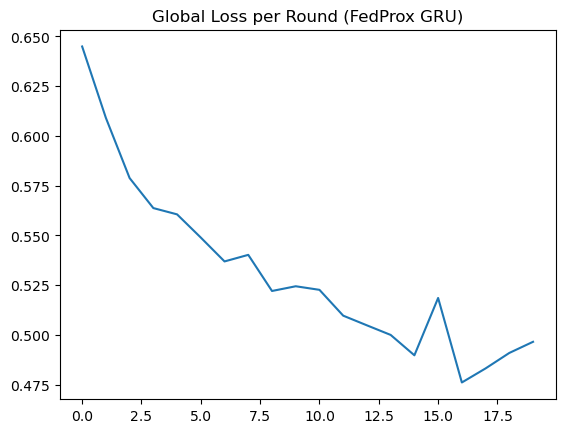

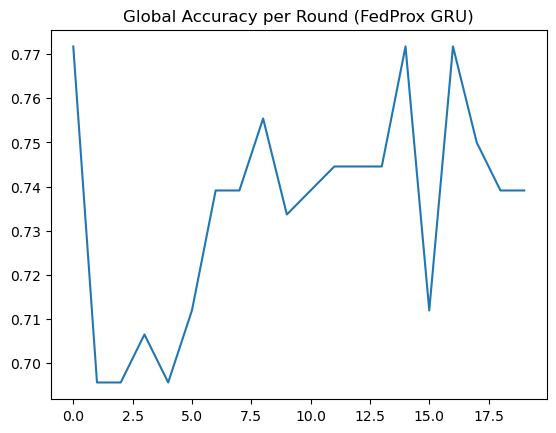

In [24]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build GRU model
# -------------------------------------------------
def build_gru(input_shape, n_classes):
    model = Sequential([
        GRU(64, return_sequences=False, input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_gru(xtrain, ytrain, xtest, ytest,
                       n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_gru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    # Initialize lists to store global metrics
    global_loss = []
    global_acc = []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx GRU)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx GRU)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_gru(xtrain, ytrain, xtest, ytest,
                                 n_clients=5, rounds=20, epochs=2, mu=0.01)


In [30]:
Global_Loss_per_Round_GRU = [0.6449348330497742, 0.6090620160102844, 0.578819215297699, 0.5637291073799133, 0.5605727434158325, 0.5489100813865662, 0.5369213223457336, 0.5402246713638306, 0.5220731496810913, 0.5244468450546265, 0.522648274898529, 0.5096749067306519, 0.5048069953918457, 0.49999237060546875, 0.4897547662258148, 0.5185616612434387, 0.4760971963405609, 0.48316702246665955, 0.490940123796463, 0.496538907289505]


Global_Accuracy_per_Round_GRU = [0.77173912525177, 0.695652186870575, 0.695652186870575, 0.70652174949646, 0.695652186870575, 0.7119565010070801, 0.739130437374115, 0.739130437374115, 0.7554348111152649, 0.7336956262588501, 0.739130437374115, 0.7445651888847351, 0.7445651888847351, 0.7445651888847351, 0.77173912525177, 0.7119565010070801, 0.77173912525177, 0.75, 0.739130437374115, 0.739130437374115]

Round 1: Loss=0.6586, Accuracy=0.7228
Round 2: Loss=0.6150, Accuracy=0.7446
Round 3: Loss=0.5780, Accuracy=0.7609
Round 4: Loss=0.5714, Accuracy=0.7500
Round 5: Loss=0.5504, Accuracy=0.7446
Round 6: Loss=0.5286, Accuracy=0.7826
Round 7: Loss=0.5262, Accuracy=0.7772
Round 8: Loss=0.5107, Accuracy=0.7826
Round 9: Loss=0.5202, Accuracy=0.7663
Round 10: Loss=0.4980, Accuracy=0.7880
Round 11: Loss=0.4806, Accuracy=0.7989
Round 12: Loss=0.4804, Accuracy=0.7717
Round 13: Loss=0.4812, Accuracy=0.7772
Round 14: Loss=0.4662, Accuracy=0.7826
Round 15: Loss=0.4541, Accuracy=0.7880
Round 16: Loss=0.4652, Accuracy=0.7826
Round 17: Loss=0.4489, Accuracy=0.7935
Round 18: Loss=0.4675, Accuracy=0.7935
Round 19: Loss=0.4537, Accuracy=0.7880
Round 20: Loss=0.4747, Accuracy=0.7880

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.91      0.78        77
           1       0.91      0.70      0.79       107

    accuracy                           0

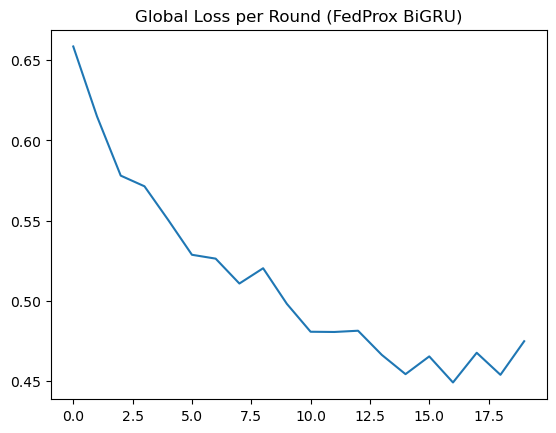

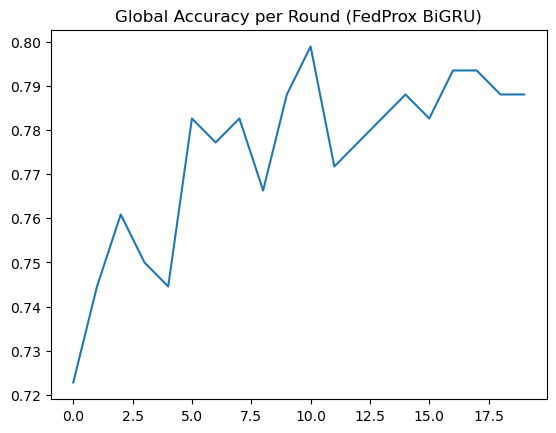

In [25]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Bidirectional, GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build BiGRU model
# -------------------------------------------------
def build_bigru(input_shape, n_classes):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_bigru(xtrain, ytrain, xtest, ytest,
                         n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for BiGRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_bigru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx BiGRU)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx BiGRU)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_bigru(xtrain, ytrain, xtest, ytest,
                                   n_clients=5, rounds=20, epochs=2, mu=0.01)


In [31]:
Global_Loss_per_Round_BiGRU = [0.6586287021636963, 0.6150000095367432, 0.5780245065689087, 0.5713706016540527, 0.5503749251365662, 0.5286304354667664, 0.5262196660041809, 0.510684609413147, 0.5202223658561707, 0.4980073571205139, 0.4805893301963806, 0.48044776916503906, 0.4812265932559967, 0.46616074442863464, 0.45412614941596985, 0.4652073085308075, 0.4489292502403259, 0.4674694538116455, 0.4537091553211212, 0.47468242049217224]

Global_Accuracy_per_Round_BiGRU = [0.7228260636329651, 0.7445651888847351, 0.760869562625885, 0.75, 0.7445651888847351, 0.782608687877655, 0.7771739363670349, 0.782608687877655, 0.7663043737411499, 0.7880434989929199, 0.7989130616188049, 0.77173912525177, 0.7771739363670349, 0.782608687877655, 0.7880434989929199, 0.782608687877655, 0.79347825050354, 0.79347825050354, 0.7880434989929199, 0.7880434989929199]

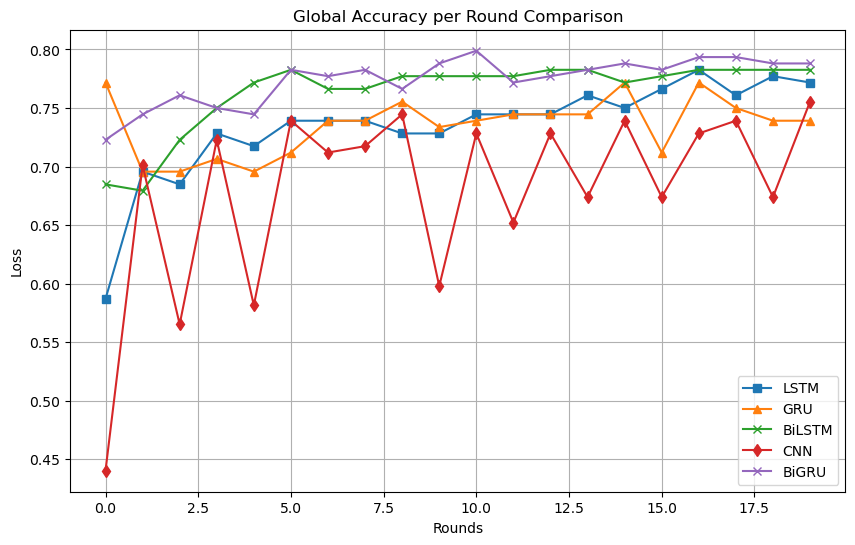

In [32]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(Global_Accuracy_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Accuracy_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Accuracy_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_accuracy_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Accuracy_per_Round_BiGRU, marker='x', label='BiGRU')

plt.title("Global Accuracy per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


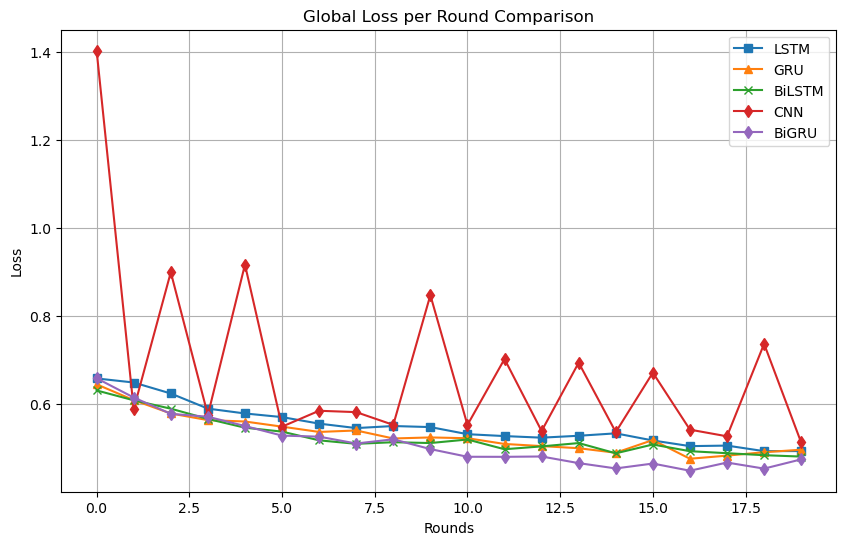

In [33]:
import matplotlib.pyplot as plt

# Plot all in one figure
plt.figure(figsize=(10,6))
plt.plot(Global_Loss_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Loss_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Loss_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_loss_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Loss_per_Round_BiGRU, marker='d', label='BiGRU')

plt.title("Global Loss per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
